## 라이브러리 호출 및 데이터 로드

In [1]:
# 라이브러리 호출
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
import platform
import ast
from collections import Counter
import json

warnings.filterwarnings('ignore')

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 컬럼 너비 제한 해제
pd.set_option('display.max_colwidth', None)

# 게임단위

#### 컬럼명세서 

##### explode_champion_items_1

- active_synergies : 활성화된 시너지 (숫자는 실제 유저가 가지고 있는 시너지의 숫자에 해당하는 최소 활성화 수치)
   - ( 시너지를 가지고 있었지만 활성화되지 않은 시너지를 가지고 있었던 경우 {}임.)  
   - 실제로 활성화된 시너지만 담긴 딕셔너리 ({} = 활성화된 시너지 없음)
- user_id : 폭발 후 헷갈리지않게 하기 위해 유저 아이디 파생 컬럼 생성
- flag_1 : 콤비네이션 O & 챔피언 X _ 1(TRUE) = 챔피언 없었다 / 0(FALSE) = 있었다 
- flag_2 : 콤비네이션 X & 챔피언 O _ 1(TRUE) = 콤비네이션 없었다 / 0(FALSE) = 있었다 
- top4_flag = ranked = 1~4 -> 1 (True) / 5~8 > 0 (False)
- ranked_1 = ranked = 1 -> 1 (True) / 2~8 > 0 (False)
- tier : 티어
- champion_name / name : 챔피언 이름
- star	: 별 ( 별 갯수가 많을수록 세다)
- items : 아이템 ID번호
- cost : 가격
- origin : 계열 시너지 
- class : 직업 시너지


#### 컬럼 명세서

##### explode_combination_1

- synergy : 활성화된 것과 활성화 되지 않은 시너지값들을 하나씩 꺼내 놓은 것. (활성화 여부 관계없이 유저가 보유한 시너지 전부 폭발)
- synergy_val : 실제 유저가 가지고 있는 시너지의 숫자. 유저가 실제로 보유한 시너지 챔피언 수 (활성화 최소 조건 미달이면 active_synergies에서 빠짐)

In [2]:
df = pd.read_csv("게임단위_게임데이터_상위랭커보존-explode_items_1.csv")

In [3]:
df.head()

,gameid,user_id,tier,ranked,ranked_1,top4_flag,champion_name,items,star,flag_1,flag_2,name,cost,origin,class,item_count,item_id,item_name
0,KR_4291707834,KR-USER-1,platinum,5,0,0,ziggs,7.0,1,0,0,ziggs,1,Rebel,Demolitionist,1,7.0,Giant's Belt
1,KR_4291707834,KR-USER-1,platinum,5,0,0,ashe,9.0,1,0,0,ashe,3,Celestial,Sniper,1,9.0,Sparring Gloves
2,KR_4291707834,KR-USER-1,platinum,5,0,0,chogath,6.0,1,0,0,chogath,4,Void,Brawler,1,6.0,Negatron Cloak
3,KR_4291707834,KR-USER-1,platinum,5,0,0,ekko,1.0,1,0,0,ekko,5,Cybernetic,Infiltrator,1,1.0,B.F. Sword
4,KR_4291707834,KR-USER-2,platinum,3,0,1,ziggs,24.0,3,0,0,ziggs,1,Rebel,Demolitionist,1,24.0,Statikk Shiv


In [53]:
df.columns

Index(['gameid', 'user_id', 'tier', 'ranked', 'ranked_1', 'top4_flag',
       'champion_name', 'items', 'star', 'flag_1', 'flag_2', 'name', 'cost',
       'origin', 'class', 'item_count', 'item_id', 'item_name'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4861833 entries, 0 to 4861832
Data columns (total 18 columns):
 #   Column         Dtype  
---  ------         -----  
 0   gameid         str    
 1   user_id        str    
 2   tier           str    
 3   ranked         int64  
 4   ranked_1       int64  
 5   top4_flag      int64  
 6   champion_name  str    
 7   items          float64
 8   star           int64  
 9   flag_1         int64  
 10  flag_2         int64  
 11  name           str    
 12  cost           int64  
 13  origin         str    
 14  class          str    
 15  item_count     int64  
 16  item_id        float64
 17  item_name      str    
dtypes: float64(2), int64(8), str(8)
memory usage: 667.7 MB


In [5]:
df_item = df.copy()

items / item_id => int 변환

In [6]:
df_2 = pd.read_csv("게임단위_게임데이터_상위랭커보존-explode_combination_1.csv")

In [7]:
df_2.head()

,gameid,user_id,tier,ranked,top4_flag,ranked_1,flag_1,flag_2,active_synergies,synergy,synergy_val
0,KR_4291707834,KR-USER-1,platinum,5,0,0,0,0,{},Cybernetic,1
1,KR_4291707834,KR-USER-1,platinum,5,0,0,0,0,{},Demolitionist,1
2,KR_4291707834,KR-USER-1,platinum,5,0,0,0,0,{},Infiltrator,1
3,KR_4291707834,KR-USER-1,platinum,5,0,0,0,0,{},Rebel,1
4,KR_4291707834,KR-USER-1,platinum,5,0,0,0,0,{},Brawler,1


In [8]:
df_combination = df_2.copy()

In [9]:
df_item['items'].isna().sum()

np.int64(1395733)

In [10]:
df_item[['champion_name', 'items', 'item_id', 'item_name']].head(10)

,champion_name,items,item_id,item_name
0,ziggs,7.0,7.0,Giant's Belt
1,ashe,9.0,9.0,Sparring Gloves
2,chogath,6.0,6.0,Negatron Cloak
3,ekko,1.0,1.0,B.F. Sword
4,ziggs,24.0,24.0,Statikk Shiv
5,fiora,37.0,37.0,Morellonomicon
6,leona,36.0,36.0,Ionic Spark
7,leona,24.0,24.0,Statikk Shiv
8,lucian,NaN,NaN,NaN
9,vi,5.0,5.0,Chain Vest


### items / item_id int 변환. 둘 중에 하나를 날려도 되나..?

In [11]:
# item_id, items NaN → 0으로 채우고 int 변환
df_item['item_id'] = df_item['item_id'].fillna(0).astype(int)
df_item['items'] = df_item['items'].fillna(0).astype(int)

# # item_name NaN → 'none'으로 채우기
# df_item['item_name'] = df_item['item_name'].fillna('none')
# item_name NaN 처리는 Tableau 전에 하기!!

# 확인
df_item[['champion_name', 'items', 'item_id', 'item_name']].head(10)

,champion_name,items,item_id,item_name
0,ziggs,7,7,Giant's Belt
1,ashe,9,9,Sparring Gloves
2,chogath,6,6,Negatron Cloak
3,ekko,1,1,B.F. Sword
4,ziggs,24,24,Statikk Shiv
5,fiora,37,37,Morellonomicon
6,leona,36,36,Ionic Spark
7,leona,24,24,Statikk Shiv
8,lucian,0,0,NaN
9,vi,5,5,Chain Vest


### champion_name & name / items & item_id 동일 여부 확인. name과 items 컬럼 날리기

In [12]:
# champion_name vs name 동일 여부 확인
print("champion_name == name 불일치 행 수:")
print((df_item['champion_name'] != df_item['name']).sum())

# items vs item_id 동일 여부 확인
print("\nitems == item_id 불일치 행 수:")
print((df_item['items'] != df_item['item_id']).sum())

champion_name == name 불일치 행 수:
0

items == item_id 불일치 행 수:
0


In [13]:
# name, items 컬럼 제거
df_item = df_item.drop(columns=['name', 'items'])

# 확인
print(df_item.columns.tolist())

['gameid', 'user_id', 'tier', 'ranked', 'ranked_1', 'top4_flag', 'champion_name', 'star', 'flag_1', 'flag_2', 'cost', 'origin', 'class', 'item_count', 'item_id', 'item_name']


In [14]:
df_item.info()

<class 'pandas.DataFrame'>
RangeIndex: 4861833 entries, 0 to 4861832
Data columns (total 16 columns):
 #   Column         Dtype
---  ------         -----
 0   gameid         str  
 1   user_id        str  
 2   tier           str  
 3   ranked         int64
 4   ranked_1       int64
 5   top4_flag      int64
 6   champion_name  str  
 7   star           int64
 8   flag_1         int64
 9   flag_2         int64
 10  cost           int64
 11  origin         str  
 12  class          str  
 13  item_count     int64
 14  item_id        int64
 15  item_name      str  
dtypes: int64(9), str(7)
memory usage: 593.5 MB


# item 데이터셋 탐색

In [15]:
# item 데이터셋 탐색
print("=== df_item ===")
print(f"shape: {df_item.shape}")
print(f"\n--- 결측값 ---")
print(df_item.isna().sum())

print(f"\n--- 챔피언 수 ---")
print(df_item['champion_name'].nunique())


=== df_item ===
shape: (4861833, 16)

--- 결측값 ---
gameid                 0
user_id                0
tier                   0
ranked                 0
ranked_1               0
top4_flag              0
champion_name          0
star                   0
flag_1                 0
flag_2                 0
cost                   0
origin                 0
class                  0
item_count             0
item_id                0
item_name        1395737
dtype: int64

--- 챔피언 수 ---
52


In [16]:
print(f"\n--- star 분포 ---")
print(df_item['star'].value_counts().sort_index())

print(f"\n--- cost 분포 ---")
print(df_item['cost'].value_counts().sort_index())



--- star 분포 ---
star
1     770779
2    3186903
3     904151
Name: count, dtype: int64

--- cost 분포 ---
cost
1     762857
2    1008488
3    1240326
4    1260990
5     589172
Name: count, dtype: int64


In [17]:
print(f"\n--- tier 분포 ---")
print(df_item['tier'].value_counts())

print(f"\n--- ranked 분포 ---")
print(df_item['ranked'].value_counts().sort_index())


--- tier 분포 ---
tier
grand_master    986641
diamond         984816
challenger      980808
master          978566
platinum        931002
Name: count, dtype: int64

--- ranked 분포 ---
ranked
1    688660
2    681798
3    650067
4    626880
5    605654
6    577314
7    542296
8    489164
Name: count, dtype: int64


In [18]:
print(f"\n--- item_id 분포 ---")
print(df_item['item_id'].value_counts().sort_index().head(20))


--- item_id 분포 ---
item_id
0     1395733
1       27760
2       40450
3       33196
4       43735
5       26596
6       27617
7       32664
8        6890
9       20179
11      39695
12     101035
13      51193
14      96051
15     219607
16      56887
17      46547
18      14628
19     147471
22      79316
Name: count, dtype: int64


In [19]:
print(f"\n--- origin, class 상위 5개 확인 ---")
print(df_item[['origin', 'class']].head(5))


--- origin, class 상위 5개 확인 ---
       origin          class
0       Rebel  Demolitionist
1   Celestial         Sniper
2        Void        Brawler
3  Cybernetic    Infiltrator
4       Rebel  Demolitionist


# Champion 데이터셋 탐색

In [20]:
print("=== df_combination ===")
print(f"shape: {df_combination.shape}")
print(f"\n--- 결측값 ---")
print(df_combination.isna().sum())

print(f"\n--- synergy 수 ---")
print(df_combination['synergy'].nunique())

=== df_combination ===
shape: (3361555, 11)

--- 결측값 ---
gameid              0
user_id             0
tier                0
ranked              0
top4_flag           0
ranked_1            0
flag_1              0
flag_2              0
active_synergies    0
synergy             0
synergy_val         0
dtype: int64

--- synergy 수 ---
23


In [21]:
print(f"\n--- synergy_val 분포 ---")
print(df_combination['synergy_val'].value_counts().sort_index())

print(f"\n--- tier 분포 ---")
print(df_combination['tier'].value_counts())


--- synergy_val 분포 ---
synergy_val
0        4875
1     1579227
2      990323
3      304161
4      356956
5       19763
6       98182
7        6824
8        1028
9         215
10          1
Name: count, dtype: int64

--- tier 분포 ---
tier
diamond         689813
grand_master    681997
master          671438
challenger      670196
platinum        648111
Name: count, dtype: int64


In [22]:
print(f"\n--- ranked 분포 ---")
print(df_combination['ranked'].value_counts().sort_index())

print(f"\n--- active_synergies top 10 ---")
print(df_combination['active_synergies'].value_counts().head(10))


--- ranked 분포 ---
ranked
1    447526
2    439564
3    432510
4    425883
5    418824
6    411251
7    400980
8    385017
Name: count, dtype: int64

--- active_synergies top 10 ---
active_synergies
{'Blaster': 4, 'Chrono': 2, 'Mercenary': 1, 'Brawler': 4}                                                        217955
{'Blaster': 4, 'Chrono': 2, 'Mercenary': 1, 'Rebel': 3, 'Brawler': 4, 'Starship': 1}                              93505
{'Blaster': 2, 'Chrono': 4, 'ManaReaver': 2, 'Mercenary': 1, 'Blademaster': 3, 'Celestial': 2, 'Valkyrie': 2}     64329
{'Blaster': 4, 'Chrono': 2, 'Mercenary': 1, 'Rebel': 3, 'Brawler': 4}                                             56554
{'Blaster': 4, 'Chrono': 2, 'Brawler': 4}                                                                         51685
{'DarkStar': 3, 'Celestial': 2, 'Mystic': 2, 'Sniper': 2, 'Vanguard': 4}                                          50359
{'Mystic': 2, 'Sorcerer': 4, 'StarGuardian': 6}                                   

In [23]:
print(f"전체 조합 종류 수: {df_combination['active_synergies'].nunique()}")
print(f"\n--- active_synergies top 10 ---")
print(df_combination['active_synergies'].value_counts().head(10))

전체 조합 종류 수: 16587

--- active_synergies top 10 ---
active_synergies
{'Blaster': 4, 'Chrono': 2, 'Mercenary': 1, 'Brawler': 4}                                                        217955
{'Blaster': 4, 'Chrono': 2, 'Mercenary': 1, 'Rebel': 3, 'Brawler': 4, 'Starship': 1}                              93505
{'Blaster': 2, 'Chrono': 4, 'ManaReaver': 2, 'Mercenary': 1, 'Blademaster': 3, 'Celestial': 2, 'Valkyrie': 2}     64329
{'Blaster': 4, 'Chrono': 2, 'Mercenary': 1, 'Rebel': 3, 'Brawler': 4}                                             56554
{'Blaster': 4, 'Chrono': 2, 'Brawler': 4}                                                                         51685
{'DarkStar': 3, 'Celestial': 2, 'Mystic': 2, 'Sniper': 2, 'Vanguard': 4}                                          50359
{'Mystic': 2, 'Sorcerer': 4, 'StarGuardian': 6}                                                                   48208
{'Chrono': 2, 'Infiltrator': 2, 'Brawler': 4, 'Sorcerer': 2, 'Void': 3}                     

### 하은님께서 유저 단위의 데이터셋으로 보신 조합 픽률 게임단위에서도 확인

In [24]:
# user_id 기준 중복 제거 후 조합 픽률
print(f"\n--- user_id 기준 중복 제거 후 조합 픽률 ---")
df_combo_dedup = df_combination.drop_duplicates(subset=['user_id'])
top_combos = df_combo_dedup['active_synergies'].value_counts(normalize=True).head(5)
print(top_combos.map(lambda x: f'{x:.2%}'))


--- user_id 기준 중복 제거 후 조합 픽률 ---
active_synergies
{'Blaster': 4, 'Chrono': 2, 'Mercenary': 1, 'Brawler': 4}                                                        6.13%
{'Blaster': 4, 'Chrono': 2, 'Mercenary': 1, 'Rebel': 3, 'Brawler': 4, 'Starship': 1}                             2.35%
{'Blaster': 4, 'Chrono': 2, 'Brawler': 4}                                                                        1.82%
{'Blaster': 2, 'Chrono': 4, 'ManaReaver': 2, 'Mercenary': 1, 'Blademaster': 3, 'Celestial': 2, 'Valkyrie': 2}    1.79%
{'Mystic': 2, 'Sorcerer': 4, 'StarGuardian': 6}                                                                  1.76%
Name: proportion, dtype: str


### synergy_val 이상치 값 확인

In [25]:
result = df_combination[df_combination['synergy_val']==10]
result

,gameid,user_id,tier,ranked,top4_flag,ranked_1,flag_1,flag_2,active_synergies,synergy,synergy_val
3117462,KR_4338954957,KR-USER-371183,challenger,1,1,1,0,0,"{'DarkStar': 9, 'Infiltrator': 2, 'Celestial': 2, 'Mystic': 2, 'Sorcerer': 2, 'Sniper': 2}",DarkStar,10


In [26]:
test = df_combination[df_combination['user_id']=='KR-USER-371183']
test

,gameid,user_id,tier,ranked,top4_flag,ranked_1,flag_1,flag_2,active_synergies,synergy,synergy_val
3117461,KR_4338954957,KR-USER-371183,challenger,1,1,1,0,0,"{'DarkStar': 9, 'Infiltrator': 2, 'Celestial': 2, 'Mystic': 2, 'Sorcerer': 2, 'Sniper': 2}",Chrono,1
3117462,KR_4338954957,KR-USER-371183,challenger,1,1,1,0,0,"{'DarkStar': 9, 'Infiltrator': 2, 'Celestial': 2, 'Mystic': 2, 'Sorcerer': 2, 'Sniper': 2}",DarkStar,10
3117463,KR_4338954957,KR-USER-371183,challenger,1,1,1,0,0,"{'DarkStar': 9, 'Infiltrator': 2, 'Celestial': 2, 'Mystic': 2, 'Sorcerer': 2, 'Sniper': 2}",Infiltrator,2
3117464,KR_4338954957,KR-USER-371183,challenger,1,1,1,0,0,"{'DarkStar': 9, 'Infiltrator': 2, 'Celestial': 2, 'Mystic': 2, 'Sorcerer': 2, 'Sniper': 2}",ManaReaver,1
3117465,KR_4338954957,KR-USER-371183,challenger,1,1,1,0,0,"{'DarkStar': 9, 'Infiltrator': 2, 'Celestial': 2, 'Mystic': 2, 'Sorcerer': 2, 'Sniper': 2}",Protector,1
3117466,KR_4338954957,KR-USER-371183,challenger,1,1,1,0,0,"{'DarkStar': 9, 'Infiltrator': 2, 'Celestial': 2, 'Mystic': 2, 'Sorcerer': 2, 'Sniper': 2}",Celestial,2
3117467,KR_4338954957,KR-USER-371183,challenger,1,1,1,0,0,"{'DarkStar': 9, 'Infiltrator': 2, 'Celestial': 2, 'Mystic': 2, 'Sorcerer': 2, 'Sniper': 2}",Mystic,2
3117468,KR_4338954957,KR-USER-371183,challenger,1,1,1,0,0,"{'DarkStar': 9, 'Infiltrator': 2, 'Celestial': 2, 'Mystic': 2, 'Sorcerer': 2, 'Sniper': 2}",Sorcerer,2
3117469,KR_4338954957,KR-USER-371183,challenger,1,1,1,0,0,"{'DarkStar': 9, 'Infiltrator': 2, 'Celestial': 2, 'Mystic': 2, 'Sorcerer': 2, 'Sniper': 2}",Sniper,2
3117470,KR_4338954957,KR-USER-371183,challenger,1,1,1,0,0,"{'DarkStar': 9, 'Infiltrator': 2, 'Celestial': 2, 'Mystic': 2, 'Sorcerer': 2, 'Sniper': 2}",Vanguard,1


In [27]:
# active_synergies가 빈 딕셔너리인지 확인
df_combination['no_combo_flag'] = df_combination['active_synergies'] == '{}'

print(df_combination['no_combo_flag'].value_counts())

no_combo_flag
False    3355225
True        6330
Name: count, dtype: int64


In [28]:
# 교차 확인
print(pd.crosstab(
    df_combination['synergy_val'] == 0, 
    df_combination['no_combo_flag'],
    rownames=['synergy_val==0'],
    colnames=['no_combo_flag']
))

no_combo_flag     False  True 
synergy_val==0                
False           3350350   6330
True               4875      0


In [29]:
# 이상한 케이스 확인
weird = df_combination[(df_combination['no_combo_flag'] == True) & (df_combination['synergy_val'] > 0)]
print(weird[['gameid', 'user_id', 'active_synergies', 'synergy', 'synergy_val']].head(10))

           gameid    user_id active_synergies        synergy  synergy_val
0   KR_4291707834  KR-USER-1               {}     Cybernetic            1
1   KR_4291707834  KR-USER-1               {}  Demolitionist            1
2   KR_4291707834  KR-USER-1               {}    Infiltrator            1
3   KR_4291707834  KR-USER-1               {}          Rebel            1
4   KR_4291707834  KR-USER-1               {}        Brawler            1
5   KR_4291707834  KR-USER-1               {}      Celestial            1
6   KR_4291707834  KR-USER-1               {}           Void            1
7   KR_4291707834  KR-USER-1               {}         Sniper            1
43  KR_4291707834  KR-USER-6               {}          Rebel            1
44  KR_4291707834  KR-USER-6               {}    Blademaster            1


#### 롤토체스 시너지 시스템
- 예를 들면:

    - Blaster 시너지 최소 활성화 수치가 2라면 → Blaster 챔피언을 2개 이상 보유해야 활성화
    - Blaster 챔피언을 1개만 가지고 있으면 → synergy_val == 1이지만 active_synergies에 Blaster가 없음

- 그래서 데이터로 보면:
    - synergy: Blaster  synergy_val: 1  →  active_synergies에 없음 (미활성)
    -synergy: Blaster  synergy_val: 2  →  active_synergies에 Blaster: 2 있음 (활성)

- 그리고 활성화 수치가 여러 단계인 시너지도 있음. 

- 예를 들면:

    - Brawler 2개 → 1단계 활성
    - Brawler 4개 → 2단계 활성 (더 강한 효과)

- 그래서 synergy_val이 높을수록 더 강한 효과를 받는 거고, 분석할 때 활성화된 것만 볼 거면 active_synergies 기준, 보유 수와 성과 관계를 볼 거면 synergy_val 기준으로 쓰면된다고함.

In [30]:
print(df_combination[df_combination['synergy_val'] == 10][['gameid', 'user_id', 'tier', 'ranked', 'synergy', 'synergy_val']])

                gameid         user_id        tier  ranked   synergy  \
3117462  KR_4338954957  KR-USER-371183  challenger       1  DarkStar   

         synergy_val  
3117462           10  


### 하은님의 유저 단위 데이터셋의 챔피언의 코스트에 따른 평균 등수 통계 시작

In [37]:
from scipy import stats
import numpy as np

# 코스트별 그룹 분리
groups = [df_item[df_item['cost'] == c]['ranked'] for c in [1,2,3,4,5]]

print("=== 코스트별 평균/중앙값/표준편차 등수 ===")
for c, g in zip([1,2,3,4,5], groups):
    print(f"cost {c}: 평균={g.mean():.4f}, 중앙값={g.median():.1f}, 표준편차={g.std():.4f}, n={len(g)}")


=== 코스트별 평균/중앙값/표준편차 등수 ===
cost 1: 평균=4.4120, 중앙값=4.0, 표준편차=2.2948, n=762857
cost 2: 평균=4.4319, 중앙값=4.0, 표준편차=2.2999, n=1008488
cost 3: 평균=4.2982, 중앙값=4.0, 표준편차=2.2694, n=1240326
cost 4: 평균=4.2302, 중앙값=4.0, 표준편차=2.2236, n=1260990
cost 5: 평균=3.7525, 중앙값=3.0, 표준편차=2.1378, n=589172


In [38]:
# 효과크기 η²_H
n = sum(len(g) for g in groups)
eta2 = (h_stat - len(groups) + 1) / (n - len(groups))
print(f"효과크기 η²_H = {eta2:.4f}")

# 크루스칼-왈리스
h_stat, p_val = stats.kruskal(*groups)
print(f"\nKruskal-Wallis: h_stat={h_stat:.4f}, p={p_val:.4e}")


효과크기 η²_H = 0.0079

Kruskal-Wallis: h_stat=38635.7888, p=0.0000e+00


게임 단위 또한 고스트별 평균 등수 차이 유의미함 -> dunn 사후 검정

In [40]:
pip install scikit-posthocs

Defaulting to user installation because normal site-packages is not writeable
  Using cached scikit_posthocs-0.12.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached statsmodels-0.14.6-cp312-cp312-win_amd64.whl.metadata (9.8 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
Using cached scikit_posthocs-0.12.0-py3-none-any.whl (36 kB)
Using cached statsmodels-0.14.6-cp312-cp312-win_amd64.whl (9.5 MB)
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\dldbs\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [41]:
from scikit_posthocs import posthoc_dunn

dunn_result = posthoc_dunn(
    df_item, val_col='ranked', group_col='cost', p_adjust='bonferroni'
)
print(dunn_result.round(4))

     1    2    3    4    5
1  1.0  0.0  0.0  0.0  0.0
2  0.0  1.0  0.0  0.0  0.0
3  0.0  0.0  1.0  0.0  0.0
4  0.0  0.0  0.0  1.0  0.0
5  0.0  0.0  0.0  0.0  1.0


### dunn 테스트 결과 : 모든 쌍이 유의미한 차이가 있다

In [42]:
import itertools

cost_labels = [1, 2, 3, 4, 5]
medians = df_item.groupby('cost')['ranked'].median()
means = df_item.groupby('cost')['ranked'].mean()

print("Dunn's 사후검정")
for c1, c2 in itertools.combinations(cost_labels, 2):
    p = dunn_result.loc[c1, c2]
    sig = "유의미한 차이 o" if p < 0.05 else "유의미한 차이 x"
    m1, m2 = medians[c1], medians[c2]
    mn1, mn2 = means[c1], means[c2]
    
    if m1 != m2:
        higher = c2 if m1 > m2 else c1
        lower = c1 if m1 > m2 else c2
        print(f"{c1}코스트 vs {c2}코스트: {sig} → {higher}코스트 중앙값({medians[higher]:.1f})이 {lower}코스트({medians[lower]:.1f})보다 등수가 높습니다")
    else:
        higher = c2 if mn1 > mn2 else c1
        lower = c1 if mn1 > mn2 else c2
        print(f"{c1}코스트 vs {c2}코스트: {sig} → 중앙값 동일({m1:.1f}), 평균 기준 {higher}코스트({means[higher]:.2f})가 {lower}코스트({means[lower]:.2f})보다 등수 높음")

Dunn's 사후검정
1코스트 vs 2코스트: 유의미한 차이 o → 중앙값 동일(4.0), 평균 기준 1코스트(4.41)가 2코스트(4.43)보다 등수 높음
1코스트 vs 3코스트: 유의미한 차이 o → 중앙값 동일(4.0), 평균 기준 3코스트(4.30)가 1코스트(4.41)보다 등수 높음
1코스트 vs 4코스트: 유의미한 차이 o → 중앙값 동일(4.0), 평균 기준 4코스트(4.23)가 1코스트(4.41)보다 등수 높음
1코스트 vs 5코스트: 유의미한 차이 o → 5코스트 중앙값(3.0)이 1코스트(4.0)보다 등수가 높습니다
2코스트 vs 3코스트: 유의미한 차이 o → 중앙값 동일(4.0), 평균 기준 3코스트(4.30)가 2코스트(4.43)보다 등수 높음
2코스트 vs 4코스트: 유의미한 차이 o → 중앙값 동일(4.0), 평균 기준 4코스트(4.23)가 2코스트(4.43)보다 등수 높음
2코스트 vs 5코스트: 유의미한 차이 o → 5코스트 중앙값(3.0)이 2코스트(4.0)보다 등수가 높습니다
3코스트 vs 4코스트: 유의미한 차이 o → 중앙값 동일(4.0), 평균 기준 4코스트(4.23)가 3코스트(4.30)보다 등수 높음
3코스트 vs 5코스트: 유의미한 차이 o → 5코스트 중앙값(3.0)이 3코스트(4.0)보다 등수가 높습니다
4코스트 vs 5코스트: 유의미한 차이 o → 5코스트 중앙값(3.0)이 4코스트(4.0)보다 등수가 높습니다


### 하은님의 분석 게임 단위에서도 진행
#### 카이제곱 독립성 검정
#### 귀무가설: 활성화된 조합 여부와 top4 여부는 독립적이다.
#### 대립가설: 활성화된 조합 여부와 top4 여부는 독립적이지 않다.

In [49]:
# user_id 기준 dedup (유저당 1행)
df_combo_user = df_combination.drop_duplicates(subset=['user_id'])
df_combo_user['has_active'] = df_combo_user['active_synergies'] != '{}'

ct = pd.crosstab(df_combo_user['has_active'], df_combo_user['top4_flag'])
print(ct)


top4_flag        0       1
has_active                
False          926     282
True        197145  197872


In [51]:
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(ct)
print(f"chi2={chi2:.4f}, p={p:.4e}")

n = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
print(f"Cramér's V: {cramers_v:.4f}")

chi2=343.5760, p=1.0619e-76
Cramér's V: 0.0294


In [52]:
total = df_combo_user.shape[0]
no_active = df_combo_user[df_combo_user['has_active'] == False].shape[0]
no_active_top4 = df_combo_user[(df_combo_user['has_active'] == False) & (df_combo_user['top4_flag'] == 1)].shape[0]
has_active_top4 = df_combo_user[(df_combo_user['has_active'] == True) & (df_combo_user['top4_flag'] == 1)].shape[0]

print(f"활성화된 조합이 없는 유저의 비율: {no_active/total*100:.2f}%")
print(f"활성화된 조합이 없는데, top4에 속한 유저의 비율: {no_active_top4/total*100:.2f}%")
print(f"활성화된 조합이 있는데, top4에 속한 유저의 비율: {has_active_top4/total*100:.2f}%")

활성화된 조합이 없는 유저의 비율: 0.30%
활성화된 조합이 없는데, top4에 속한 유저의 비율: 0.07%
활성화된 조합이 있는데, top4에 속한 유저의 비율: 49.94%


게임 단위에서 볼 수 있는 통계가 적어서 2차 전처리 완료 데이터에서 'gameduration', 'ingameduration', 'lastroundlevel' 컬럼 이어 붙여 오기로

In [55]:
# 원본 match 데이터 읽기
df_match = pd.read_csv("게임단위_게임데이터_상위랭커보존-2차 전처리 완료(match).csv")

df_match_sub = df_match[['gameid', 'user_id', 'gameduration', 'ingameduration', 'lastround', 'level']].drop_duplicates()

df_item = df_item.merge(df_match_sub, on=['gameid', 'user_id'], how='left')

# 확인
print(df_item[['gameid', 'user_id', 'gameduration', 'ingameduration', 'lastround', 'level']].head())
print(df_item[['gameduration', 'ingameduration', 'lastround', 'level']].isna().sum())

          gameid    user_id  gameduration  ingameduration  lastround  level
0  KR_4291707834  KR-USER-1   1963.905273     1390.165771         27      6
1  KR_4291707834  KR-USER-1   1963.905273     1390.165771         27      6
2  KR_4291707834  KR-USER-1   1963.905273     1390.165771         27      6
3  KR_4291707834  KR-USER-1   1963.905273     1390.165771         27      6
4  KR_4291707834  KR-USER-2   1963.905273     1891.282715         37      8
gameduration      0
ingameduration    0
lastround         0
level             0
dtype: int64


In [57]:
df_item.info()

<class 'pandas.DataFrame'>
RangeIndex: 4861833 entries, 0 to 4861832
Data columns (total 20 columns):
 #   Column          Dtype  
---  ------          -----  
 0   gameid          str    
 1   user_id         str    
 2   tier            str    
 3   ranked          int64  
 4   ranked_1        int64  
 5   top4_flag       int64  
 6   champion_name   str    
 7   star            int64  
 8   flag_1          int64  
 9   flag_2          int64  
 10  cost            int64  
 11  origin          str    
 12  class           str    
 13  item_count      int64  
 14  item_id         int64  
 15  item_name       str    
 16  gameduration    float64
 17  ingameduration  float64
 18  lastround       int64  
 19  level           int64  
dtypes: float64(2), int64(11), str(7)
memory usage: 741.9 MB


# 게임 단위 통계 시작
### level과 등수

방향 1: 스피어만 _ ranked가 순위형 데이터 (1~8등)라서 피어슨보다 스피어만이 적합

귀무가설: level과 ranked 사이에 상관관계가 없다 (ρ = 0)

대립가설: level이 높을수록 ranked가 낮다 (ρ < 0) → 단측검정

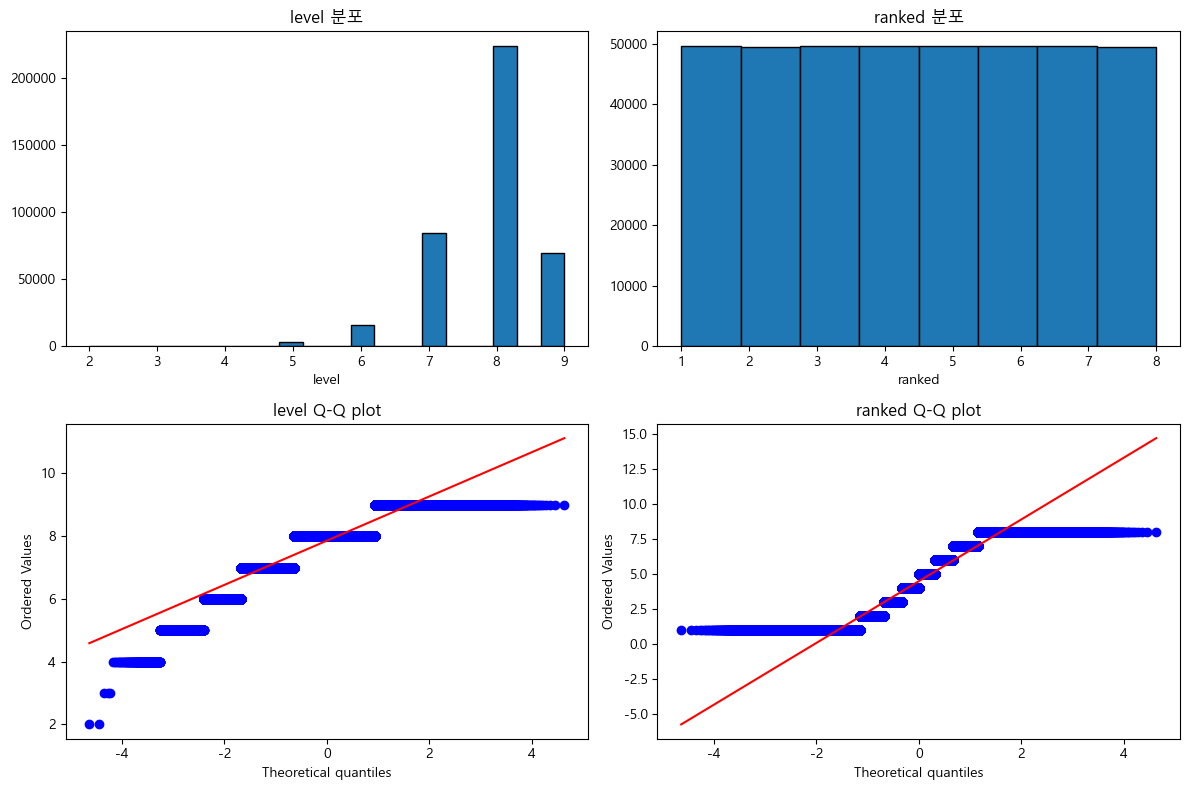

In [61]:
import matplotlib.pyplot as plt
import scipy.stats as stats

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# level 히스토그램
axes[0, 0].hist(df_user['level'], bins=20, edgecolor='black')
axes[0, 0].set_title('level 분포')
axes[0, 0].set_xlabel('level')

# ranked 히스토그램
axes[0, 1].hist(df_user['ranked'], bins=8, edgecolor='black')
axes[0, 1].set_title('ranked 분포')
axes[0, 1].set_xlabel('ranked')

# level Q-Q plot
stats.probplot(df_user['level'], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('level Q-Q plot')

# ranked Q-Q plot
stats.probplot(df_user['ranked'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('ranked Q-Q plot')

plt.tight_layout()
plt.show()

level → 2~9 사이 정수값, 게다가 상위 랭커 데이터라 8~9에 몰릴 수밖에 없음

ranked → 1~8 사이 정수값, 게임 구조상 8명이 1~8등을 하나씩 가져가니까 균등분포에 가까울 수밖에 없음

둘 다 이산형 데이터이고 범위가 제한되어 있어서 정규분포 자체가 불가능한 구조


In [136]:
from scipy import stats

# gameid를 포함하여 유저+게임별로 1행씩 남깁니다.
df_user = df_item.drop_duplicates(subset=['gameid', 'user_id'])[['gameid', 'user_id', 'tier', 'ranked', 'top4_flag', 'level', 'lastround', 'ingameduration']].reset_index(drop=True)

print(f"유저 수: {df_user.shape[0]}")
print(df_user[['level', 'ranked', 'top4_flag']].describe())

유저 수: 396190
               level         ranked      top4_flag
count  396190.000000  396190.000000  396190.000000
mean        7.858129       4.499205       0.500109
std         0.774965       2.290938       0.500001
min         2.000000       1.000000       0.000000
25%         7.000000       2.000000       0.000000
50%         8.000000       4.000000       1.000000
75%         8.000000       6.000000       1.000000
max         9.000000       8.000000       1.000000


In [137]:
df_user.columns

Index(['gameid', 'user_id', 'tier', 'ranked', 'top4_flag', 'level',
       'lastround', 'ingameduration'],
      dtype='str')

In [139]:
# 다시 CSV로 저장 (인코딩 주의)
df_user.to_csv('tft_user_level_data_v2.csv', index=False, encoding='utf-8-sig')

print("✅ gameid가 포함된 df_user 파일이 생성되었습니다!")

✅ gameid가 포함된 df_user 파일이 생성되었습니다!


In [120]:
# 방향 1: 단측 스피어만 (level 높을수록 ranked 낮다 = 음의 상관)
corr, p = stats.spearmanr(df_user['level'], df_user['ranked'], alternative='less')
print(f"스피어만 상관계수: {corr:.4f}, p={p:.4e}")
print(f"p(단측)={p/2:.4e}")  # 단측은 양측 p값을 2로 나눔

스피어만 상관계수: -0.4860, p=0.0000e+00
p(단측)=0.0000e+00


- 스피어만 상관계수: -0.4860
- p값: 0.0000 → 귀무가설 기각

- 음의 상관관계 확인 → level이 높을수록 ranked 숫자가 작아짐 (성과 좋음)
- 상관계수 -0.49는 중간 정도의 상관관계
- level 평균이 7.86, 최댓값 9인 걸 보면 상위 랭커들은 대부분 레벨을 높게 올리는 편

결론: 대립가설 채택 — level이 높을수록 유의미하게 성과가 좋다

### 방향 2: 맨-휘트니 U 

- top4_flag가 이진(0/1)이라서 두 그룹 비교 → t검정 대신 비파라메트릭인 맨-휘트니

귀무가설: top4 그룹과 non-top4 그룹의 level 분포는 같다

대립가설: top4 그룹의 level이 non-top4 그룹보다 높다 → 단측검정 (alternative='greater')

In [121]:
# 방향 2: 맨-휘트니 U
top4 = df_user[df_user['top4_flag'] == 1]['level']
non_top4 = df_user[df_user['top4_flag'] == 0]['level']
stat, p_mw = stats.mannwhitneyu(top4, non_top4, alternative='greater')
print(f"맨-휘트니 U: stat={stat:.4f}, p={p_mw:.4e}")
print(f"top4 level 평균: {top4.mean():.4f}")
print(f"non_top4 level 평균: {non_top4.mean():.4f}")

맨-휘트니 U: stat=28087304267.5000, p=0.0000e+00
top4 level 평균: 8.1780
non_top4 level 평균: 7.5381


맨-휘트니 p = 0.0000, top4 평균 8.18 > non_top4 평균 7.54 → 유의미

In [122]:
# 맨-휘트니 효과크기 (U통계량 기반 직접 계산)
n1, n2 = len(top4), len(non_top4)
u_stat = stat  # 위에서 구한 stat값
r_effect = 1 - (2 * u_stat) / (n1 * n2)
print(f"효과크기 r: {r_effect:.4f}")

효과크기 r: -0.4315


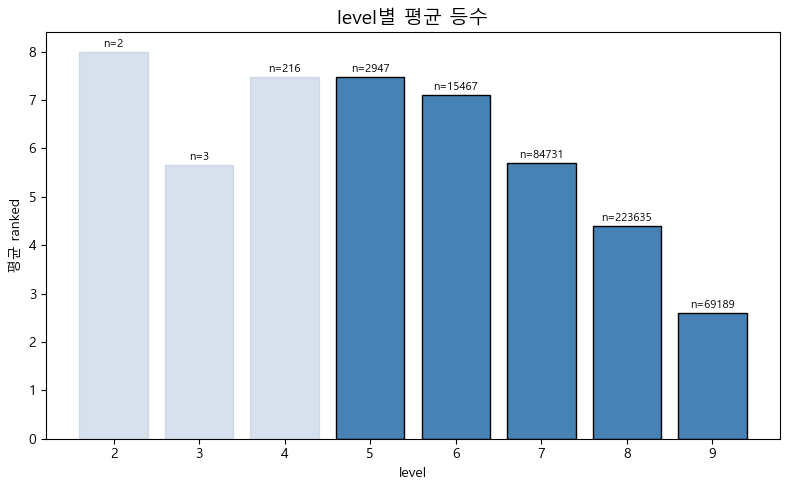

In [123]:
fig, ax = plt.subplots(figsize=(8, 5))

level_stats = df_user.groupby('level')['ranked'].agg(['mean', 'count'])

bars = ax.bar(level_stats.index, level_stats['mean'], edgecolor='black', color='steelblue')

# 데이터 수 적은 bar 색 다르게
for i, (idx, row) in enumerate(level_stats.iterrows()):
    if row['count'] < 1000:
        bars[i].set_color('lightsteelblue')
        bars[i].set_alpha(0.5)

# 각 bar 위에 n수 표시
for i, (idx, row) in enumerate(level_stats.iterrows()):
    ax.text(idx, row['mean'] + 0.1, f"n={int(row['count'])}", 
            ha='center', fontsize=8)

ax.set_title('level별 평균 등수', fontsize=14)
ax.set_xlabel('level')
ax.set_ylabel('평균 ranked')
ax.set_xticks(level_stats.index)

plt.tight_layout()
plt.show()

#### level이 높을수록 성과가 좋다

#### 추가 가설 1: ingameduration이 길수록 성과가 좋다

귀무가설: ingameduration과 ranked 사이에 상관관계가 없다

대립가설: ingameduration이 길수록 ranked가 낮다 (음의 상관) → 단측검정

스피어만을 쓰는 이유

ingameduration은 연속형, ranked는 순위형(1~8) → 두 변수 간 상관관계 분석

ranked가 순위형 데이터라서 피어슨보다 스피어만이 적합

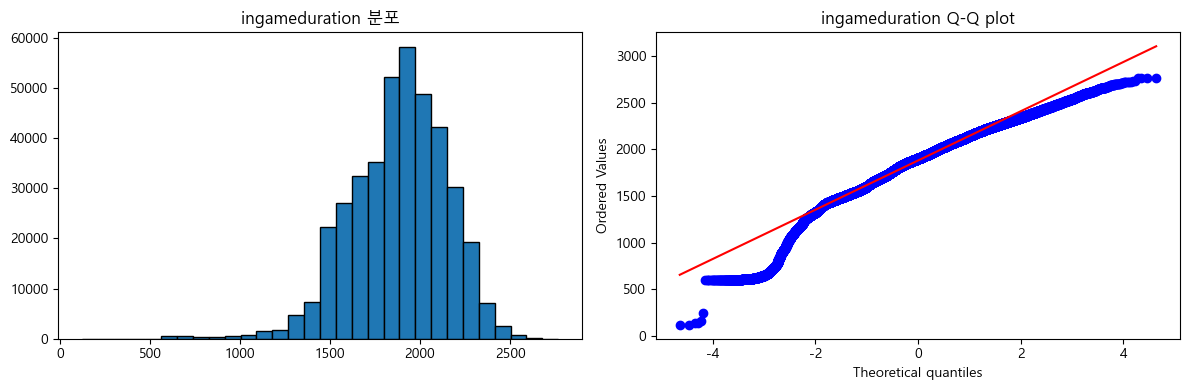

In [124]:
# 정규성 확인
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_user['ingameduration'], bins=30, edgecolor='black')
axes[0].set_title('ingameduration 분포')

stats.probplot(df_user['ingameduration'], dist="norm", plot=axes[1])
axes[1].set_title('ingameduration Q-Q plot')

plt.tight_layout()
plt.show()

히스토그램: 종 모양에 가깝지만 왼쪽 꼬리가 있음 → 완전한 정규분포 아님

Q-Q plot: 하단부에서 직선 벗어남 → 정규성 불만족

In [125]:
# 스피어만 상관계수
corr, p = stats.spearmanr(df_user['ingameduration'], df_user['ranked'], alternative='less')
print(f"스피어만 상관계수: {corr:.4f}, p={p:.4e}")

스피어만 상관계수: -0.8602, p=0.0000e+00


r = -0.8602, p = 0.0000

|r| = 0.86 -> 강한 상관

귀무가설 기각 → 대립가설 채택

In [126]:
# 맨-휘트니 U (top4랑 같이 비교)
top4_ing = df_user[df_user['top4_flag'] == 1]['ingameduration']
non_top4_ing = df_user[df_user['top4_flag'] == 0]['ingameduration']
stat_ing, p_mw_ing = stats.mannwhitneyu(top4_ing, non_top4_ing, alternative='greater')
print(f"맨-휘트니 U: stat={stat_ing:.4f}, p={p_mw_ing:.4e}")
print(f"top4 ingameduration 평균: {top4_ing.mean():.4f}")
print(f"non_top4 ingameduration 평균: {non_top4_ing.mean():.4f}")

# 효과크기
n1, n2 = len(top4_ing), len(non_top4_ing)
r_effect = 1 - (2 * stat_ing) / (n1 * n2)
print(f"효과크기 r: {abs(r_effect):.4f}")

맨-휘트니 U: stat=36990513990.5000, p=0.0000e+00
top4 ingameduration 평균: 2069.0505
non_top4 ingameduration 평균: 1691.1771
효과크기 r: 0.8853


p = 0.0000 → 유의미

top4 평균: 2069.05초 vs non_top4 평균: 1691.18초

효과크기 r = 0.8853 → 강한 효과크기

결론: ingameduration이 길수록 성과가 좋다 → 두 방향 모두 강하게 지지

ValueError: Could not interpret value `top4_label` for `x`. An entry with this name does not appear in `data`.

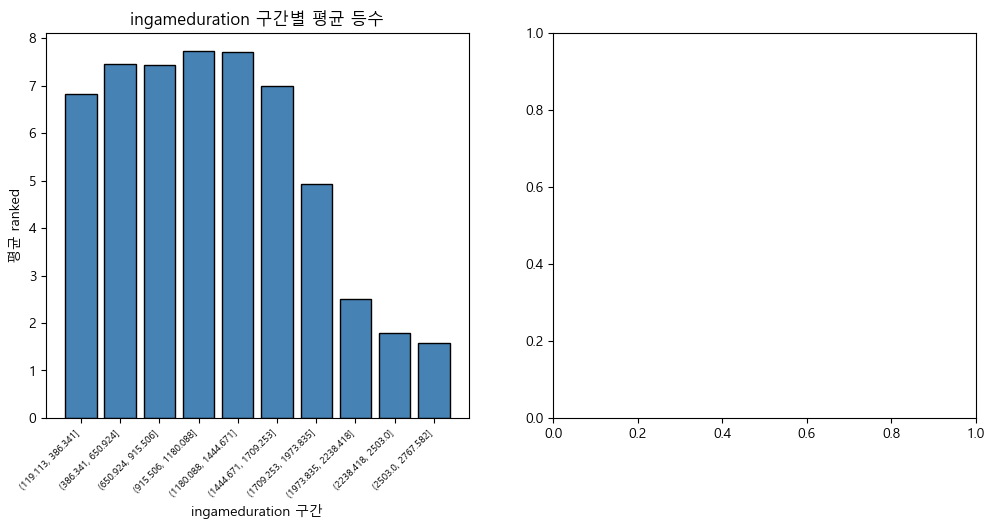

In [128]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. ingameduration 구간별 평균 ranked
df_user['ing_bin'] = pd.cut(df_user['ingameduration'], bins=10)
ing_ranked = df_user.groupby('ing_bin')['ranked'].mean()

axes[0].bar(range(len(ing_ranked)), ing_ranked.values, edgecolor='black', color='steelblue')
axes[0].set_xticks(range(len(ing_ranked)))
axes[0].set_xticklabels([str(x) for x in ing_ranked.index], rotation=45, ha='right', fontsize=7)
axes[0].set_title('ingameduration 구간별 평균 등수')
axes[0].set_xlabel('ingameduration 구간')
axes[0].set_ylabel('평균 ranked')

# 2. top4 vs non_top4 박스플롯
sns.boxplot(data=df_user, x='top4_label', y='ingameduration', ax=axes[1])
axes[1].set_title(f'top4 여부별 ingameduration 분포\n(spearman r=-0.8602)')
axes[1].set_xlabel('top4 여부')
axes[1].set_ylabel('ingameduration')

plt.tight_layout()
plt.show()

In [129]:
# 구간별 표본 수 확인
ing_stats = df_user.groupby('ing_bin')['ranked'].agg(['mean', 'count'])
print(ing_stats)

                          mean   count
ing_bin                               
(119.113, 386.341]    6.833333       6
(386.341, 650.924]    7.457038     547
(650.924, 915.506]    7.432318    1182
(915.506, 1180.088]   7.725258    2708
(1180.088, 1444.671]  7.716396   13741
(1444.671, 1709.253]  6.985360   81828
(1709.253, 1973.835]  4.923491  145355
(1973.835, 2238.418]  2.497569  121165
(2238.418, 2503.0]    1.787742   28715
(2503.0, 2767.582]    1.568399     943


- 왼쪽 바차트

1,444초 이후부터 명확하게 등수가 낮아지는 패턴

2,500초 이상 구간은 평균 등수 1.6 → 거의 1등에 가까움

- 오른쪽 박스플롯

top4가 non_top4보다 ingameduration이 확연히 높음 

top4 중앙값 약 2,100초 vs non_top4 중앙값 약 1,700초

도메인적으로 당연한 것이라서 확인을 안할까하다가 혹시나 하고 확인해봄.

650초 이전 구간은 표본이 매우 적어 해석에 주의 필요. 

1,180초 이후부터는 표본이 충분하며 1,444초 이후부터 등수가 명확하게 낮아지는 패턴이 나타남.

#### 추가 가설 2: lastround가 길수록 성과가 좋다

귀무가설: lastround와 ranked 사이에 상관관계가 없다

대립가설: lastround가 길수록 ranked가 낮다 (음의 상관) → 단측검정

스피어만을 쓰는 이유

lastround는 이산형 정수, ranked는 순위형 → 두 변수 간 상관관계 분석

둘 다 순위/이산형이라 스피어만이 적합

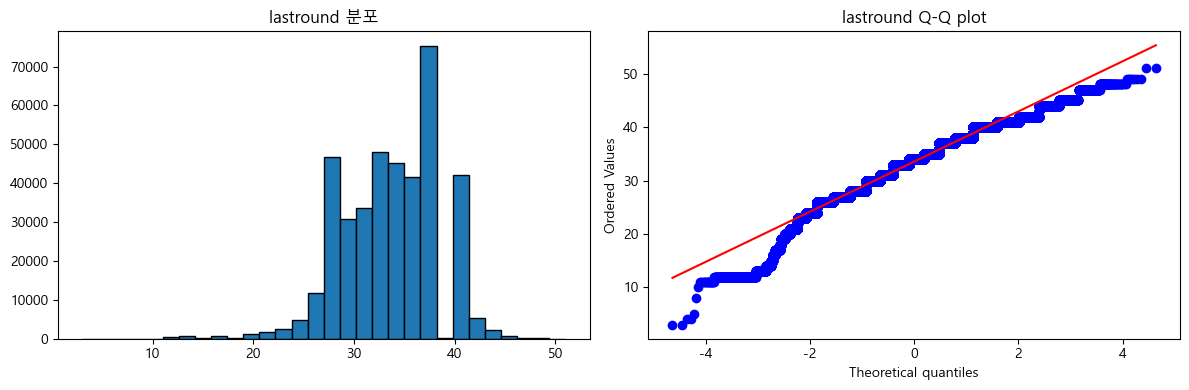

In [79]:
# 정규성 확인
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_user['lastround'], bins=30, edgecolor='black')
axes[0].set_title('lastround 분포')

stats.probplot(df_user['lastround'], dist="norm", plot=axes[1])
axes[1].set_title('lastround Q-Q plot')

plt.tight_layout()
plt.show()

In [80]:
# 스피어만
corr, p = stats.spearmanr(df_user['lastround'], df_user['ranked'], alternative='less')
print(f"스피어만 상관계수: {corr:.4f}, p={p:.4e}")


스피어만 상관계수: -0.8886, p=0.0000e+00


스피어만 r = -0.8886 → 강한 음의 상관
p = 0.0000 → 유의미

In [83]:
# 맨-휘트니
top4_lr = df_user[df_user['top4_flag'] == 1]['lastround']
non_top4_lr = df_user[df_user['top4_flag'] == 0]['lastround']
stat_lr, p_mw_lr = stats.mannwhitneyu(top4_lr, non_top4_lr, alternative='greater')
n1, n2 = len(top4_lr), len(non_top4_lr)
r_effect_lr = 1 - (2 * stat_lr) / (n1 * n2)
print(f"맨-휘트니 U: stat={stat_lr:.4f}, p={p_mw_lr:.4e}")
print(f"top4 lastround 평균: {top4_lr.mean():.4f}")
print(f"non_top4 lastround 평균: {non_top4_lr.mean():.4f}")# 효과크기
print(f"효과크기 r: {abs(r_effect_lr):.4f}")

맨-휘트니 U: stat=37529815442.0000, p=0.0000e+00
top4 lastround 평균: 37.0528
non_top4 lastround 평균: 30.0702
효과크기 r: 0.9128


효과크기 r = 0.9128 → 강한 효과크기

top4(37라운드) vs non_top4(30라운드) 평균 차이가 7라운드라서 실제 게임에서 체감되는 차이가 크지 않을 수 있음

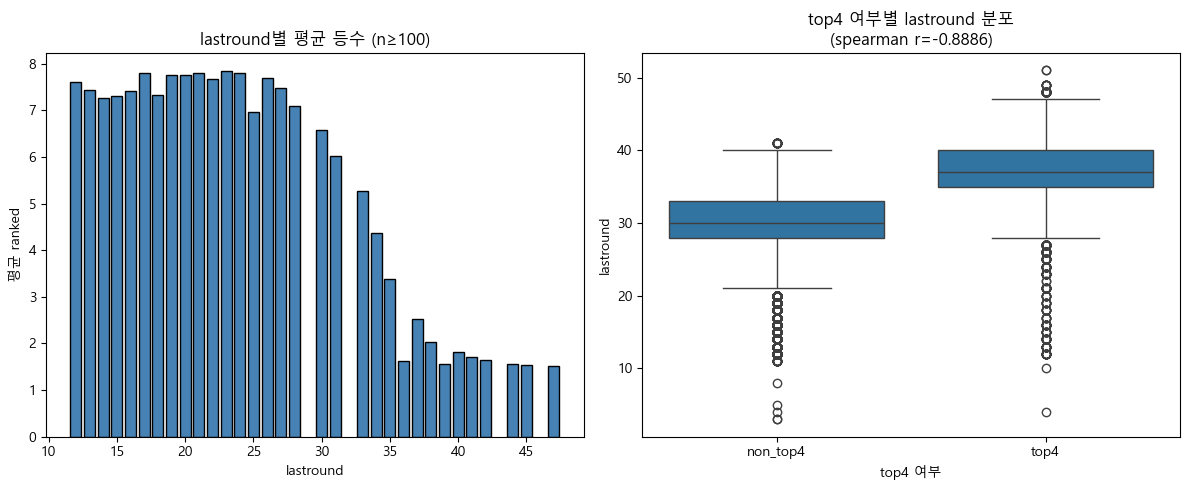

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. lastround별 평균 ranked (표본 충분한 구간만)
lr_stats2 = df_user.groupby('lastround')['ranked'].agg(['mean', 'count'])
lr_filtered = lr_stats2[lr_stats2['count'] >= 100]

axes[0].bar(lr_filtered.index, lr_filtered['mean'], edgecolor='black', color='steelblue')
axes[0].set_title('lastround별 평균 등수 (n≥100)')
axes[0].set_xlabel('lastround')
axes[0].set_ylabel('평균 ranked')

# 2. top4 vs non_top4 박스플롯
sns.boxplot(data=df_user, x='top4_label', y='lastround', ax=axes[1])
axes[1].set_title(f'top4 여부별 lastround 분포\n(spearman r=-0.8886)')
axes[1].set_xlabel('top4 여부')
axes[1].set_ylabel('lastround')

plt.tight_layout()
plt.show()

- 왼쪽 바차트

라운드 30까지는 평균 등수가 7~8로 높음 (성과 나쁨)

라운드 30 이후부터 급격하게 등수가 낮아지는 패턴

라운드 35 이후는 평균 등수 2~3대로 매우 좋음

- 오른쪽 박스플롯

top4 중앙값 약 37라운드 vs non_top4 중앙값 약 30라운드

차이가 시각적으로 명확하게 보임.

non_top4에 이상치(outlier)가 꽤 많은듯 → 라운드가 짧은데 top4 못 든 케이스들일까?

In [85]:
lr_stats = df_user.groupby('lastround')['ranked'].agg(['mean', 'count'])
print(lr_stats)

               mean  count
lastround                 
3          8.000000      2
4          4.500000      2
5          8.000000      1
8          8.000000      1
10         1.000000      1
11         7.588235     17
12         7.603645    439
13         7.425428    409
14         7.270627    303
15         7.296875    128
16         7.416667    228
17         7.792035    452
18         7.333333    147
19         7.748387    465
20         7.761966    773
21         7.799340   1515
22         7.671875    128
23         7.838848   2569
24         7.790059   4587
25         6.960870    230
26         7.698921  11678
27         7.481826  19754
28         7.102541  26877
29         6.347826     69
30         6.587711  30646
31         6.020840  33589
32         4.452381     84
33         5.278420  47960
34         4.369849  45159
35         3.387433  41473
36         1.633484    221
37         2.524718  40132
38         2.024514  35164
39         1.558824    204
40         1.812667  28484
4

#### 가설 4: 티어가 높을수록 lastround가 길다

귀무가설: tier와 lastround 사이에 상관관계가 없다

대립가설: tier가 높을수록 lastround가 길다 (양의 상관) → 단측검정

스피어만을 쓰는 이유

tier는 명목형이지만 순서가 있는 순서형 (platinum < diamond < master < grandmaster < challenger) → 숫자로 인코딩 후 스피어만 적용 가능

lastround는 이산형 정수

In [89]:
tier_order = {'platinum': 1, 'diamond': 2, 'master': 3, 'grand_master': 4, 'challenger': 5}
df_user['tier_num'] = df_user['tier'].map(tier_order)
print(df_user['tier_num'].value_counts().sort_index())

tier_num
1    76945
2    79456
3    79923
4    79953
5    79913
Name: count, dtype: int64


숫자가 높을수록 높은 티어

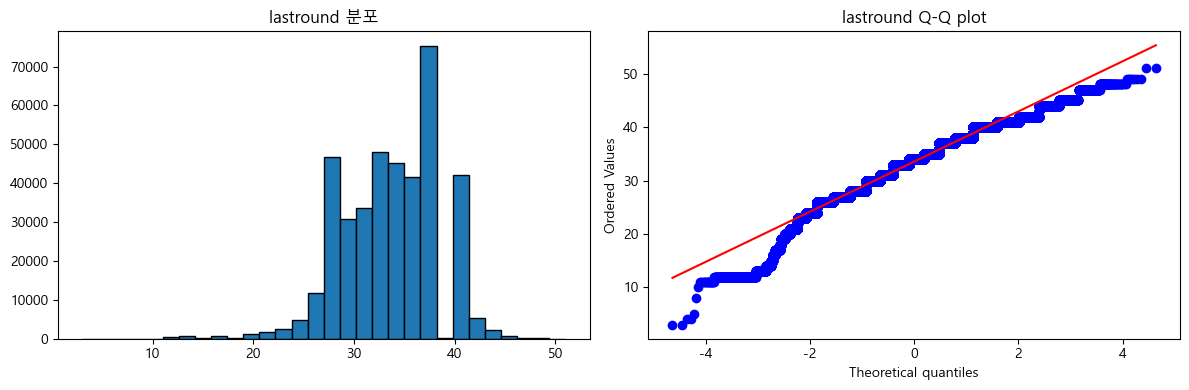

In [90]:
# 정규성 확인
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_user['lastround'], bins=30, edgecolor='black')
axes[0].set_title('lastround 분포')

stats.probplot(df_user['lastround'], dist="norm", plot=axes[1])
axes[1].set_title('lastround Q-Q plot')

plt.tight_layout()
plt.show()

히스토그램: 왼쪽 치우침 → 정규분포 아님

Q-Q plot: 하단부 직선 벗어남 → 정규성 불만족

In [91]:
# 스피어만
corr, p = stats.spearmanr(df_user['tier_num'], df_user['lastround'], alternative='greater')
print(f"스피어만 상관계수: {corr:.4f}, p={p:.4e}")

# 티어별 lastround 평균/중앙값
print(df_user.groupby('tier')['lastround'].agg(['mean', 'median', 'count']))

스피어만 상관계수: 0.0278, p=7.3310e-69
                   mean  median  count
tier                                  
challenger    33.769124    34.0  79913
diamond       33.593133    34.0  79456
grand_master  33.594262    34.0  79953
master        33.541271    34.0  79923
platinum      33.303931    34.0  76945


결과 해석:

스피어만 r = 0.0278 → 거의 상관 없음

p = 7.33e-69 → 유의미하긴 하지만 샘플이 많아서 나온 것

티어별 평균 lastround: challenger 33.77 ~ platinum 33.30 → 거의 차이 없음

중앙값은 모든 티어가 34.0으로 동일

결론: 귀무가설 기각 못 함 → 티어가 높아도 lastround는 거의 같다

In [92]:
import numpy as np

# 샘플 수를 줄여서 여러 번 반복 검정
np.random.seed(42)
n_samples = 1000  # 티어당 1000명씩
n_iter = 100      # 100번 반복

corr_list = []
p_list = []

for _ in range(n_iter):
    sample = df_user.groupby('tier').sample(n=n_samples, random_state=np.random.randint(0, 10000))
    corr_s, p_s = stats.spearmanr(sample['tier_num'], sample['lastround'], alternative='greater')
    corr_list.append(corr_s)
    p_list.append(p_s)

print(f"평균 상관계수: {np.mean(corr_list):.4f}")
print(f"상관계수 범위: {np.min(corr_list):.4f} ~ {np.max(corr_list):.4f}")
print(f"유의미한 비율 (p<0.05): {sum(p < 0.05 for p in p_list) / n_iter * 100:.1f}%")

평균 상관계수: 0.0283
상관계수 범위: -0.0061 ~ 0.0667
유의미한 비율 (p<0.05): 61.0%


샘플 수가 많을 때 p값 문제를 해결하는 방법으로 부트스트랩 샘플링을 쓰면 된다고함 (클로드 추천)

- 부트스트랩 결과:

평균 상관계수: 0.0283 → 여전히 거의 상관 없음

상관계수 범위: -0.0061 ~ 0.0667 → 음수도 나옴 (방향도 일관되지 않음)

유의미한 비율: 61% → 100번 중 39번은 유의미하지 않음

결론: 귀무가설 채택 → 티어와 lastround는 실질적인 상관관계가 없다

전체 샘플로 봤을 때 p값이 유의미하게 나온 건 순전히 샘플 수 효과였고, 실제로는 상관관계가 거의 없다

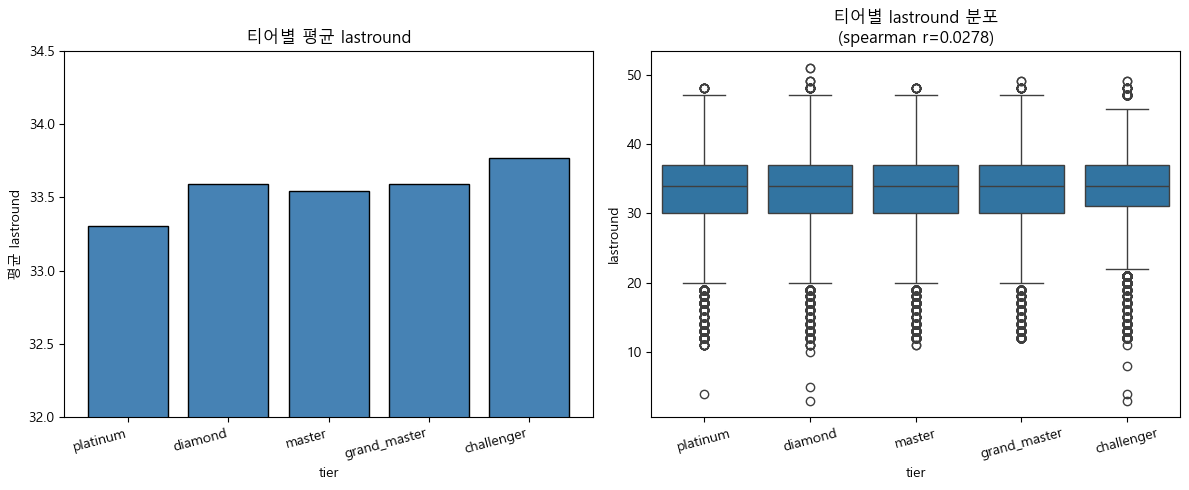

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. 티어별 lastround 평균 바차트
tier_order_label = ['platinum', 'diamond', 'master', 'grand_master', 'challenger']
tier_stats = df_user.groupby('tier')['lastround'].mean().reindex(tier_order_label)

axes[0].bar(range(len(tier_stats)), tier_stats.values, edgecolor='black', color='steelblue')
axes[0].set_xticks(range(len(tier_stats)))
axes[0].set_xticklabels(tier_order_label, rotation=15, ha='right')
axes[0].set_title('티어별 평균 lastround')
axes[0].set_xlabel('tier')
axes[0].set_ylabel('평균 lastround')
axes[0].set_ylim(32, 34.5)  # 차이 강조

# 2. 티어별 lastround 박스플롯
sns.boxplot(data=df_user, x='tier', y='lastround', order=tier_order_label, ax=axes[1])
axes[1].set_title(f'티어별 lastround 분포\n(spearman r=0.0278)')
axes[1].set_xlabel('tier')
axes[1].set_ylabel('lastround')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

- 왼쪽 바차트

y축 범위가 32~34.5로 좁아서 차이가 있어 보이지만 실제로는 0.5 라운드 차이에 불과해요

platinum 33.3 ~ challenger 33.8 → 거의 동일

- 오른쪽 박스플롯

5개 티어의 박스 크기, 중앙값, 분포가 거의 동일

이상치 패턴도 모든 티어에서 비슷하게 나타남

한 가지 주의할 점 — 왼쪽 바차트는 y축을 32부터 시작함! 0부터 시작하면 차이가 거의 없음.

In [96]:
df_item.info()

<class 'pandas.DataFrame'>
RangeIndex: 4861833 entries, 0 to 4861832
Data columns (total 20 columns):
 #   Column          Dtype  
---  ------          -----  
 0   gameid          str    
 1   user_id         str    
 2   tier            str    
 3   ranked          int64  
 4   ranked_1        int64  
 5   top4_flag       int64  
 6   champion_name   str    
 7   star            int64  
 8   flag_1          int64  
 9   flag_2          int64  
 10  cost            int64  
 11  origin          str    
 12  class           str    
 13  item_count      int64  
 14  item_id         int64  
 15  item_name       str    
 16  gameduration    float64
 17  ingameduration  float64
 18  lastround       int64  
 19  level           int64  
dtypes: float64(2), int64(11), str(7)
memory usage: 741.9 MB


In [97]:
df_combination.info()

<class 'pandas.DataFrame'>
RangeIndex: 3361555 entries, 0 to 3361554
Data columns (total 12 columns):
 #   Column            Dtype
---  ------            -----
 0   gameid            str  
 1   user_id           str  
 2   tier              str  
 3   ranked            int64
 4   top4_flag         int64
 5   ranked_1          int64
 6   flag_1            int64
 7   flag_2            int64
 8   active_synergies  str  
 9   synergy           str  
 10  synergy_val       int64
 11  no_combo_flag     bool 
dtypes: bool(1), int64(6), str(5)
memory usage: 285.3 MB


### [가설 5] 3성 챔피언 보유 여부와 등수

귀무가설: 3성 챔피언 보유 여부에 따라 평균 등수에 차이가 없다.

대립가설: 3성 챔피언을 보유한 유저가 보유하지 않은 유저보다 평균 등수가 더 높을(숫자는 낮을) 것이다.

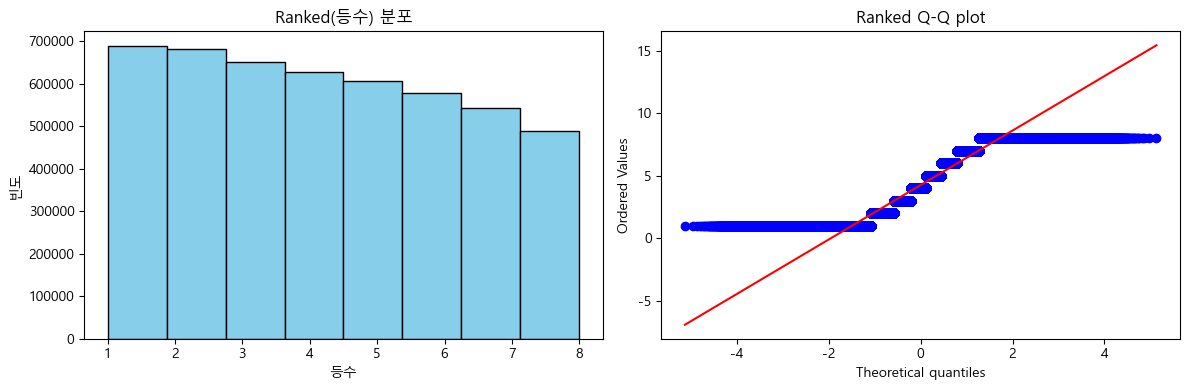

In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# 가설 5 & 16의 종속변수인 'ranked'에 대한 정규성 확인
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1. 히스토그램
axes[0].hist(df_item['ranked'], bins=8, edgecolor='black', color='skyblue')
axes[0].set_title('Ranked(등수) 분포')
axes[0].set_xlabel('등수')
axes[0].set_ylabel('빈도')

# 2. Q-Q Plot
stats.probplot(df_item['ranked'], dist="norm", plot=axes[1])
axes[1].set_title('Ranked Q-Q plot')

plt.tight_layout()
plt.show()

종속변수인 ranked의 분포를 확인한 결과, 

히스토그램이 종 모양을 띠지 않고 Q-Q Plot에서 정규성 가정을 크게 벗어남을 확인.

따라서 모수 검정(t-test, ANOVA) 대신 비모수 검정인 Mann-Whitney U와 Kruskal-Wallis 검정을 채택하여 분석을 진행

In [100]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

# 1. 유저별 3성 보유 여부 및 등수 추출
# (df_item에서 gameid, user_id별로 3성이 하나라도 있는지 체크)
user_3star_status = df_item.groupby(['gameid', 'user_id']).agg({
    'star': lambda x: (x == 3).any(),
    'ranked': 'first'
}).reset_index()

user_3star_status.columns = ['gameid', 'user_id', 'has_3star', 'ranked']

# 2. 그룹 분리
group_yes = user_3star_status[user_3star_status['has_3star'] == True]['ranked']
group_no = user_3star_status[user_3star_status['has_3star'] == False]['ranked']

# 3. 맨-휘트니 U 검정 실시
u_stat, p_val = mannwhitneyu(group_yes, group_no, alternative='less') # 3성 보유 시 등수가 더 '작을(낮을)' 것이므로 less

# 4. 효과크기(r) 계산
n1, n2 = len(group_yes), len(group_no)
z = (u_stat - (n1 * n2 / 2)) / np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
r_val = abs(z / np.sqrt(n1 + n2))

print(f"--- 가설 5 분석 결과 ---")
print(f"3성 보유 유저 수: {n1:,}명 / 평균 등수: {group_yes.mean():.2f}등")
print(f"3성 미보유 유저 수: {n2:,}명 / 평균 등수: {group_no.mean():.2f}등")
print(f"p-value: {p_val:.4f}")
print(f"효과크기 (r): {r_val:.4f}")

if p_val < 0.05:
    print("결론: 귀무가설을 기각합니다. 3성 보유 여부는 등수에 유의미한 차이를 만듭니다.")
else:
    print("결론: 귀무가설을 채택합니다. 3성 보유 여부와 등수는 유의미한 차이가 없습니다.")

--- 가설 5 분석 결과 ---
3성 보유 유저 수: 198,657명 / 평균 등수: 3.92등
3성 미보유 유저 수: 197,533명 / 평균 등수: 5.09등
p-value: 0.0000
효과크기 (r): 0.2532
결론: 귀무가설을 기각합니다. 3성 보유 여부는 등수에 유의미한 차이를 만듭니다.


해석 : 약하지만 유의미한 상관관계

p-value = 0.0000

귀무가설을 기각.

평균 등수 차이: 1.17

3성 챔피언을 하나라도 완성했을 때, 유저는 평균적으로 'Top 4(순방)' 안으로 진입할 확률 높은 편.

반면 미보유 시에는 평균 5등으로 떨어지며 점수를 잃을 확률이 큼.

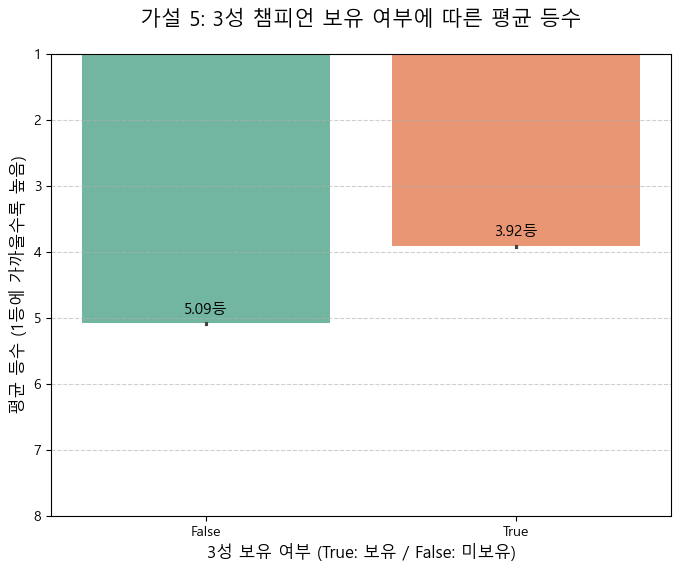

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

# 가설 5: 3성 보유 여부별 평균 등수
# user_3star_status: ['gameid', 'user_id', 'has_3star', 'ranked'] 구조
ax = sns.barplot(data=user_3star_status, x='has_3star', y='ranked', palette='Set2')

# 시각적 직관성을 위한 처리
plt.title('가설 5: 3성 챔피언 보유 여부에 따른 평균 등수', fontsize=15, pad=20)
plt.xlabel('3성 보유 여부 (True: 보유 / False: 미보유)', fontsize=12)
plt.ylabel('평균 등수 (1등에 가까울수록 높음)', fontsize=12)

# Y축 반전: 1등이 가장 높게 보이도록 설정 (중요!)
plt.gca().invert_yaxis() 
plt.ylim(8, 1) # 8등부터 1등까지 범위 고정

# 바 위에 수치 표시 (Annotate)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}등', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 10),
                textcoords='offset points')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

### [가설 16] 성급(Star)에 따른 등수 차이

귀무가설: 챔피언의 성급(1, 2, 3성)에 따라 등수에 차이가 없다.

대립가설: 챔피언의 성급이 높을수록(1성 < 2성 < 3성) 해당 유저의 등수가 더 높을 것이다.

In [101]:
import pandas as pd
from scipy.stats import kruskal
import scikit_posthocs as sp # 사후 검정을 위해 필요

# 1. 크루스칼-왈리스 검정 (df_item의 전체 행 기준)
h_stat, p_val_k = kruskal(
    df_item[df_item['star'] == 1]['ranked'],
    df_item[df_item['star'] == 2]['ranked'],
    df_item[df_item['star'] == 3]['ranked']
)

# 2. 성급별 평균 등수 확인
star_means = df_item.groupby('star')['ranked'].mean()

print(f"--- 가설 16 분석 결과 ---")
print(f"성급별 평균 등수:\n{star_means}")
print(f"Kruskal-Wallis p-value: {p_val_k:.4f}")

# 3. 사후 검정 (Dunn's test) - 구체적으로 어떤 성급 간에 차이가 나는지 확인
if p_val_k < 0.05:
    print("\n--- 사후 검정 (Dunn's Test) ---")
    dunn_df = sp.posthoc_dunn(df_item, val_col='ranked', group_col='star', p_adjust='bonferroni')
    print(dunn_df)

--- 가설 16 분석 결과 ---
성급별 평균 등수:
star
1    5.024083
2    4.303910
3    3.453974
Name: ranked, dtype: float64
Kruskal-Wallis p-value: 0.0000

--- 사후 검정 (Dunn's Test) ---
     1    2    3
1  1.0  0.0  0.0
2  0.0  1.0  0.0
3  0.0  0.0  1.0


Kruskal-Wallis 결과 : p-value: 0.0000

사후 검정 (Dunn's Test) 결과 1-2성 사이, 2-3성 사이, 1-3성 사이 모든 조합에서 p-value가 0에 가까움.

즉, 성급이 한 단계 올라갈 때마다 등수가 유의미하게 상승한다는 것이 통계적으로 확정.

귀무가설 기각!

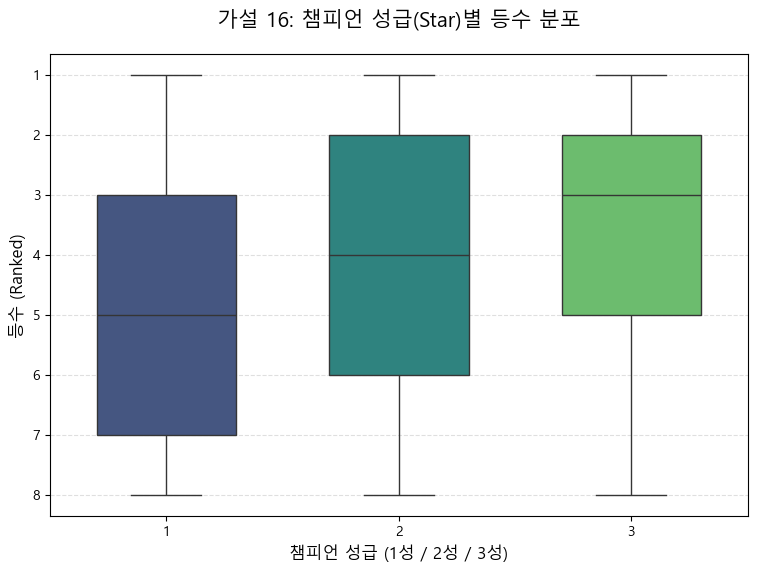

In [110]:
plt.figure(figsize=(9, 6))

# 가설 16: 성급별 등수 분포
# df_item: ['star', 'ranked'] 구조
sns.boxplot(data=df_item, x='star', y='ranked', palette='viridis', width=0.6)

plt.title('가설 16: 챔피언 성급(Star)별 등수 분포', fontsize=15, pad=20)
plt.xlabel('챔피언 성급 (1성 / 2성 / 3성)', fontsize=12)
plt.ylabel('등수 (Ranked)', fontsize=12)

# Y축 반전: 1등이 위로 오게
plt.gca().invert_yaxis()
plt.yticks(range(1, 9)) # 1~8등 딱 떨어지게 표시

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

### 컬럼들간의 상관관계를 확인 안해봐서 히트맵 보기

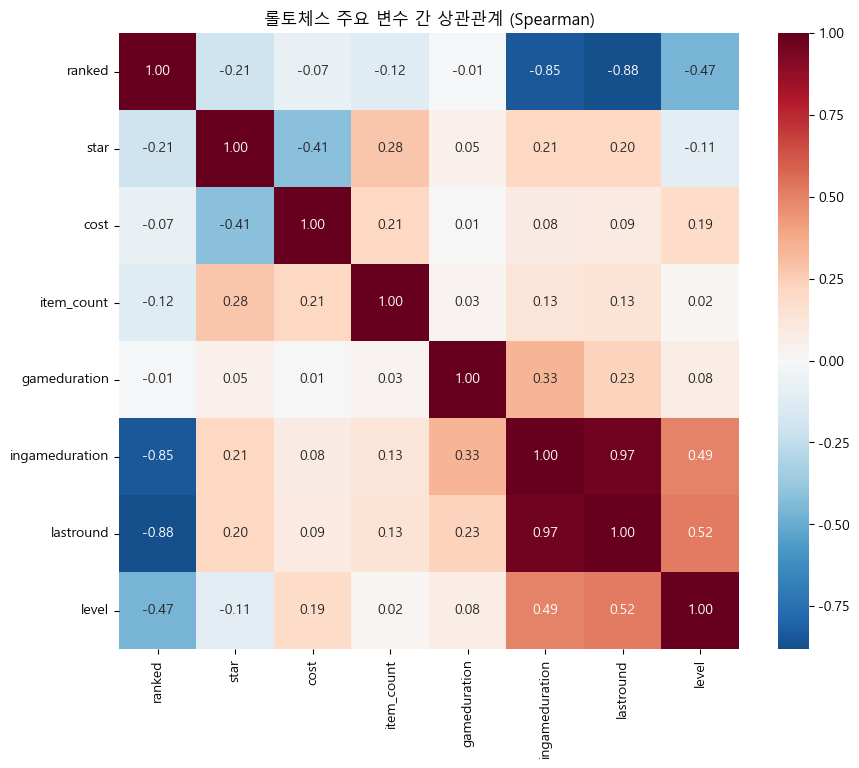

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 수치형 컬럼만 선택
# info()에서 확인한 int64, float64 타입 컬럼들 위주
cols = ['ranked', 'star', 'cost', 'item_count', 'gameduration', 'ingameduration', 'lastround', 'level']
df_corr = df_item[cols].corr(method='spearman') # 순위형 데이터이므로 스피어만 추천

# 2. 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('롤토체스 주요 변수 간 상관관계 (Spearman)')
plt.show()

1. "생존이 곧 승리다" (압도적인 상관관계)
ranked vs lastround (-0.88) & ingameduration (-0.85)
이 수치는 엄청나게 강력한 상관관계. "오래 버티는 놈이 이긴다"는 당연한 사실을 넘어서, 롤토체스에서 등수를 결정짓는 가장 지배적인 변수가 '생존 라운드'임을 보여줌.
대시보드 시각화 시, 이 두 변수는 성과 지표의 '기준점'으로 삼으면 될지도.
롤토체스에서 등수(ranked)는 숫자가 작을수록(1등) 좋은 것이기 때문에, 다른 변수(레벨, 라운드 등)가 커질수록 등수 숫자가 작아지는 음의 상관관계가 나타나는 것이 정상

2. "레벨업 vs 성급(3성), 무엇이 더 중요한가?" (가설 14 vs 16)
ranked vs level (-0.47): 중간 정도의 꽤 높은 상관관계.
ranked vs star (-0.21): 약한 상관관계.
인사이트: 데이터상으로는 단순히 특정 기물을 3성 찍는 것(star)보다, 시너지를 추가하거나 고코스트 기물을 넣는 level업 전략이 등수 상승에 더 일관된 영향력을 미친다고 해석 할 수 있음.

3. "돈 값을 하는 고코스트 기물"
star vs cost (-0.41): 음의 상관관계가 뚜렷.
해석: 코스트가 높은 기물일수록 3성을 찍기가 훨씬 어렵다는 게임의 제약 조건을 그대로 보여줌. 고코스트의 낮은 성급과 저코스트의 높은 성급 사이의 성과 비교가 매우 의미 있는 분석일지도.

4. "아이템의 영향력"
ranked vs item_count (-0.12): 생각보다 상관계수가 낮음.
해석: 단순히 아이템이 '많다'는 것 자체보다는, '누구에게 어떤 핵심 아이템을 주었는가'라는 질적 분석(가설 19번)이 훨씬 중요하다는 것을 보여줌.

결론: 오래 살아남는(lastround) 것이 승리의 절대 원칙.

하지만 오래 살아남기 위해서는 '3성'에 집착하기보다 '레벨업'을 통한 밸류업 전략(level)이 더 효과적.

아이템(item_count)은 다다익선이 아님. 챔피언과의 궁합이 성패를 가른다.

### 가설 19: 특정 아이템 보유 시 평균 성과가 좋다

귀무가설: 아이템 종류에 따라 평균 등수에 차이가 없다.

대립가설: 특정 아이템(소위 '1티어 아이템')을 보유했을 때 평균 등수가 유의미하게 높을(낮은 숫자) 것이다.

--- 가설 19 분석 결과 (아이템 성과) ---
Kruskal-Wallis p-value: 0.0000

[평균 등수 상위 10개 아이템 (n>=100)]
                    item_name      mean  count
39        Shroud of Stillness  3.462923  37935
29     Protector's Chestguard  3.657054  18102
33                Rebel Medal  3.674771  18138
24  Locket of the Iron Solari  3.678673  47808
51              Zeke's Herald  3.746708  46547
45              Sword Breaker  3.767679  34956
7           Dark Star's Heart  3.774977  14243
49                  Trap Claw  3.776282  67804
36                 Redemption  3.781956  71238
1    Blade of the Ruined King  3.859995  14628


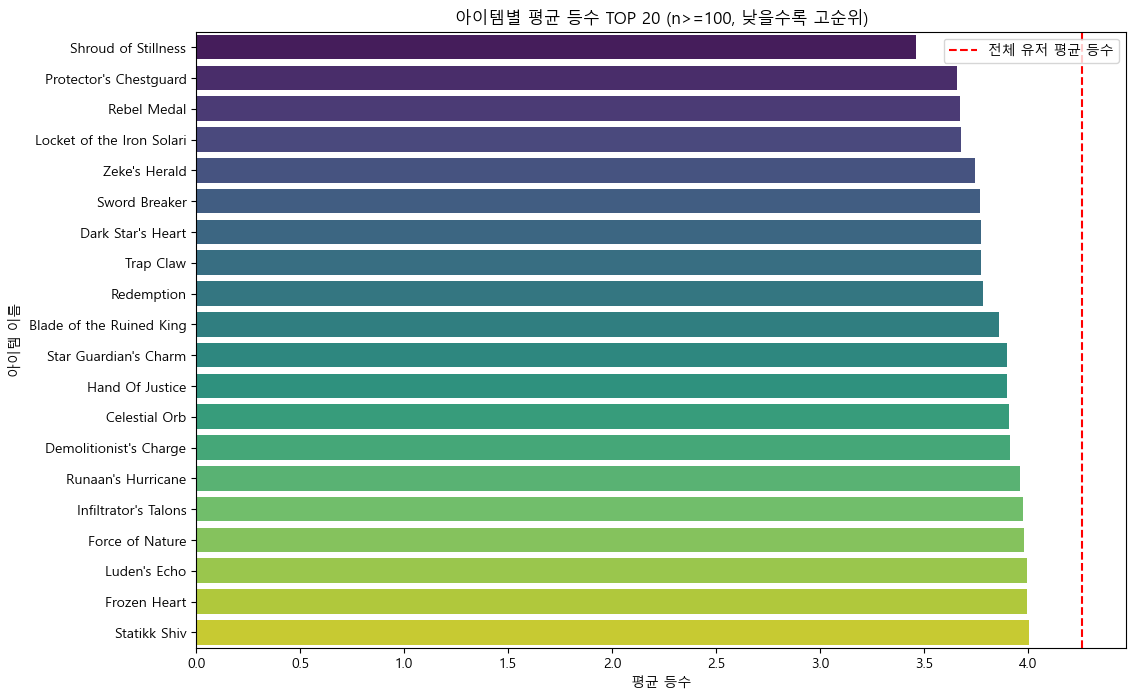

In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal

# 1. 아이템이 있는 데이터만 필터링 (NaN 제외)
# 결측치(NaN)가 있는 행을 제거하여 실제 아이템 데이터만 확보합니다.
df_valid_items = df_item.dropna(subset=['item_name']).copy()

# 2. 아이템별 평균 등수 계산 및 샘플 수(n) 파악
item_stats = df_valid_items.groupby('item_name')['ranked'].agg(['mean', 'count']).reset_index()

# 너무 적게 나타난 아이템은 신뢰도가 낮으므로, 최소 100회 이상 등장한 아이템만 필터링
item_stats = item_stats[item_stats['count'] >= 100]
item_stats = item_stats.sort_values(by='mean') # 평균 등수 좋은 순(작은 숫자 순)

# 3. 통계적 유의성 검정 (Kruskal-Wallis)
# 상위 30개 아이템들 사이에 등수 차이가 통계적으로 유의미한지 확인
top_30_names = item_stats['item_name'].head(30).tolist()
groups = [df_valid_items[df_valid_items['item_name'] == name]['ranked'] for name in top_30_names]
h_stat, p_val = kruskal(*groups)

print(f"--- 가설 19 분석 결과 (아이템 성과) ---")
print(f"Kruskal-Wallis p-value: {p_val:.4f}")
print(f"\n[평균 등수 상위 10개 아이템 (n>=100)]")
print(item_stats.head(10))

# 4. 시각화: 상위 20개 아이템의 평균 등수
plt.figure(figsize=(12, 8))
sns.barplot(data=item_stats.head(20), x='mean', y='item_name', palette='viridis')

# 전체 평균 등수 가이드라인 (아이템 보유 여부와 상관없는 전체 유저 평균)
plt.axvline(df_item['ranked'].mean(), color='red', linestyle='--', label='전체 유저 평균 등수')
plt.title('아이템별 평균 등수 TOP 20 (n>=100, 낮을수록 고순위)')
plt.xlabel('평균 등수')
plt.ylabel('아이템 이름')
plt.legend()
plt.show()

 (n >= 100 기준)

특징: 아주 희귀한 아이템까지 모두 포함된 결과.

순위권 아이템: Protector's Chestguard, Rebel Medal, Dark Star's Heart 등

이 아이템들은 '뒤집개'로 만드는 시너지 아이템들 이라고함. 

보통 게임이 아주 잘 풀렸을 때나 고밸류 조합을 완성했을 때만 나오기 때문에, 

등장 횟수(count)는 적지만 평균 등수는 매우 높게(3.6~3.7등) 형성.

장점: "어떤 시너지가 가장 사기인가?"를 볼 수 있음.

"시너지의 강력함을 보여주고 싶다" 일 때 사용

분석에 포함된 최소 등장 횟수 기준: 19428회
Kruskal-Wallis p-value: 0.0000

[평균 등수 상위 10개 아이템]
                     item_name      mean  count
39        Shroud of Stillness  3.462923  37935
24  Locket of the Iron Solari  3.678673  47808
51              Zeke's Herald  3.746708  46547
45              Sword Breaker  3.767679  34956
49                  Trap Claw  3.776282  67804
36                 Redemption  3.781956  71238
17            Hand Of Justice  3.900369  56709
4               Celestial Orb  3.908165  23967
9      Demolitionist's Charge  3.915493  35299
37         Runaan's Hurricane  3.962570  62517


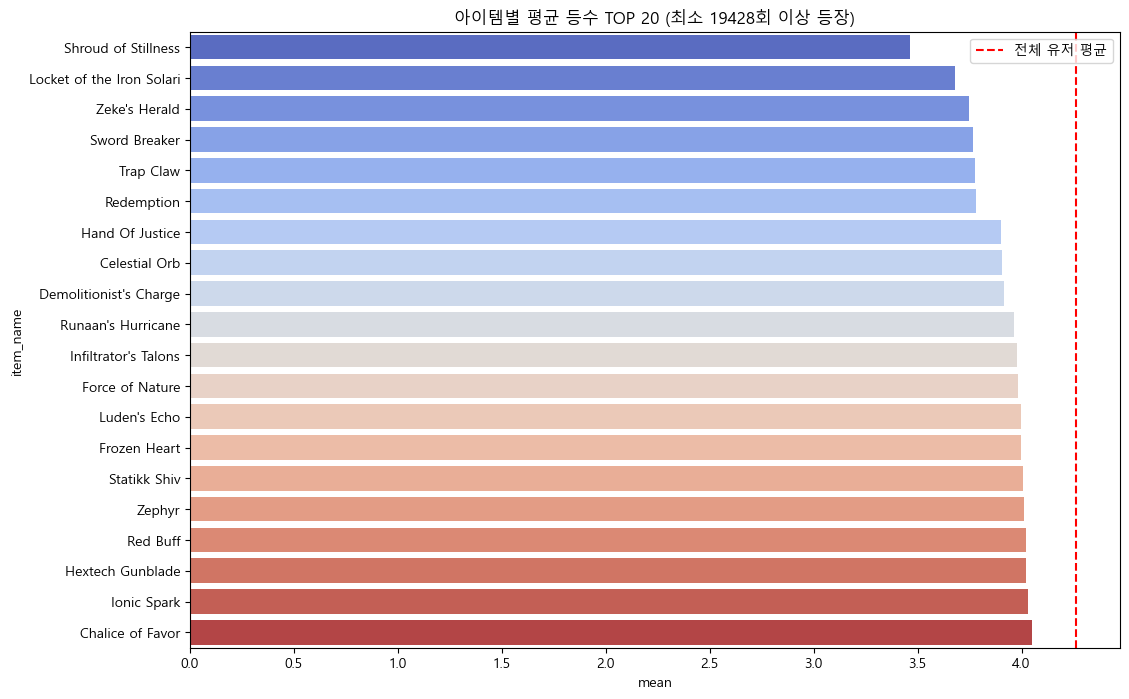

In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal

# 1. 아이템이 있는 데이터만 필터링 (NaN 제외)
df_valid_items = df_item.dropna(subset=['item_name']).copy()

# 2. 아이템별 평균 등수 및 빈도 계산
item_stats = df_valid_items.groupby('item_name')['ranked'].agg(['mean', 'count']).reset_index()


# 하위 10% 빈도 아이템 제거 (데이터 규모 고려 추천)
min_count = item_stats['count'].quantile(0.1) 
item_stats = item_stats[item_stats['count'] >= min_count]

print(f"분석에 포함된 최소 등장 횟수 기준: {min_count:.0f}회")
# ---------------------------------------------------------

# 3. 평균 등수 좋은 순(작은 숫자 순)으로 정렬
item_stats = item_stats.sort_values(by='mean')

# 4. 통계적 유의성 검정 (상위 30개 아이템 대상)
top_30_names = item_stats['item_name'].head(30).tolist()
groups = [df_valid_items[df_valid_items['item_name'] == name]['ranked'] for name in top_30_names]
h_stat, p_val = kruskal(*groups)

print(f"Kruskal-Wallis p-value: {p_val:.4f}")
print(f"\n[평균 등수 상위 10개 아이템]\n", item_stats.head(10))

# 5. 시각화
plt.figure(figsize=(12, 8))
sns.barplot(data=item_stats.head(20), x='mean', y='item_name', palette='coolwarm')
plt.axvline(df_item['ranked'].mean(), color='red', linestyle='--', label='전체 유저 평균')
plt.title(f'아이템별 평균 등수 TOP 20 (최소 {min_count:.0f}회 이상 등장)')
plt.legend()
plt.show()

(n >= 19428 기준 - 하위 10% 제거)

특징: 누구나 범용적으로 만들 수 있는 '메이저 아이템' 위주의 결과.

순위권 아이템: Shroud of Stillness(침묵의 장막), Locket of the Iron Solari(솔라리), Zeke's Herald(지크) 등

이유: min_count가 19,428회로 껑충 뛰면서, 뒤집개 템처럼 희귀한 아이템들은 통계에서 탈락. 

대신 많이 쓰이면서도 승률이 좋은 '유틸리티/서포팅 아이템'들이 상위권을 차지.

장점: "현실적으로 어떤 아이템을 만들어야 순방을 잘 하는가?"를 보여줌.

" 일반적인 운영 팁을 주고 싶다 " 일때 사용



제미나이는 두 번째 결과를 대시보드 메인으로 쓰는 걸 추천한다고함. 

Shroud of Stillness(장막)가 1위인 걸 보니, 

시즌3 당시 상위권 랭커들이 상대 배치를 카운터 치는 

아이템을 얼마나 중요하게 생각했는지 아주 잘 보여주는 지표라고함

### 가설 13: 특정 시너지는 1위 달성률이 유독 높은가?

귀무가설: 모든 시너지의 1위 달성 확률은 동일하다(전체 평균 1위 확률과 같다).

대립가설: 특정 시너지는 전체 평균보다 유의미하게 높은 1위 달성 확률을 가진다.

분석 방향 (이항 검정 - Binomial Test)

각 시너지가 '1등을 했느냐(Success) 아니냐(Failure)'의 이진 분류이므로, 

이항 검정을 통해 해당 시너지의 우승 확률이 우연인지 실력인지 판별합니다.

이항 분포(Binomial Distribution)**가 표본이 커질수록 **정규 분포(Z-분포)**에 가까워진다는 중심극한정리

In [115]:
import pandas as pd
import numpy as np
from scipy.stats import binomtest 

# 1. 전체 유저 중 1위 비중 계산 (기준값)
total_users = df_combination[['gameid', 'user_id']].drop_duplicates().shape[0]
total_wins = df_combination[df_combination['ranked'] == 1][['gameid', 'user_id']].drop_duplicates().shape[0]
base_win_rate = total_wins / total_users

print(f"전체 평균 1위 달성 확률: {base_win_rate:.4f}\n")

# 2. 시너지별 집계
synergy_stats = df_combination.groupby('synergy').agg({
    'ranked': lambda x: (x == 1).sum(),
    'gameid': 'count'
}).rename(columns={'ranked': 'win_count', 'gameid': 'total_count'})

synergy_stats['win_rate'] = synergy_stats['win_count'] / synergy_stats['total_count']

# 3. 이항 검정 (Binomial Test) 실시
def get_p_val(row):
    # binomtest(성공횟수, 총횟수, 예상확률).pvalue
    result = binomtest(int(row['win_count']), int(row['total_count']), base_win_rate, alternative='greater')
    return result.pvalue

synergy_stats['p_value'] = synergy_stats.apply(get_p_val, axis=1)

# 4. 결과 출력 (n이 너무 적은 건 제외하고 정렬)
significant_synergies = synergy_stats[synergy_stats['total_count'] > 100].sort_values(by='win_rate', ascending=False)

print("[1위 달성률 유의미하게 높은 상위 시너지]")
print(significant_synergies[['win_count', 'total_count', 'win_rate', 'p_value']].head(10))

전체 평균 1위 달성 확률: 0.1251

[1위 달성률 유의미하게 높은 상위 시너지]
               win_count  total_count  win_rate        p_value
synergy                                                       
Starship            4697        23200  0.202457  6.295302e-241
Mercenary          20353       127225  0.159976  8.014970e-289
Mystic             21914       139474  0.157119  1.495155e-268
StarGuardian       14086       101027  0.139428   2.573784e-42
Valkyrie           24759       178515  0.138694   3.340369e-66
Celestial          24795       180385  0.137456   8.788512e-56
DarkStar           25943       189037  0.137238   2.034086e-56
Demolitionist      12295        90313  0.136138   1.496552e-23
MechPilot           9228        67887  0.135932   1.426176e-17
Sorcerer           18376       135959  0.135158   4.890386e-29


In [116]:
# 1. 통계 분석용 원본 유지 (기존 df_item 그대로 사용)
# 이 데이터는 NaN이 살아있어서 dropna() 등을 활용한 통계 검정에 계속 쓰입니다.

# 2. 팀원 공유 및 태블로용 데이터 생성 (복사본)
df_item_shared = df_item.copy()
df_item_shared['item_name'] = df_item_shared['item_name'].fillna('none')

# 3. 각각 다른 이름으로 저장
# 분석용 (나중에 마스터님이 다시 불러올 때 사용)
df_item.to_csv('tft_item_raw_for_stats.csv', index=False, encoding='utf-8-sig')

# 공유용 (팀원들에게 전달하고 태블로에 연결할 파일)
df_item_shared.to_csv('tft_item_shared_none_filled.csv', index=False, encoding='utf-8-sig')

print("✅ 파일 분리 완료!")
print("- 원본(NaN 포함): tft_item_raw_for_stats.csv")
print("- 공유용(none 처리): tft_item_shared_none_filled.csv")

✅ 파일 분리 완료!
- 원본(NaN 포함): tft_item_raw_for_stats.csv
- 공유용(none 처리): tft_item_shared_none_filled.csv


In [118]:
df_user.to_csv('tft_user_level_data.csv', index=False, encoding='utf-8-sig')